In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:/XYZ/commercial_real_estate_clean.csv", encoding='utf-8')

In [3]:
data.head(5)

,Unnamed: 0,title,price,nbn,address,text,area,type,lattitude,longitude
0,0,"325 Balwyn Road, Balwyn North, VIC 3104 - Sale...","$868,000",Service Available - Hybrid Fibre Coaxial (HFC),"325 Balwyn Road, Balwyn North, VIC",POINT OF INTEREST:\nWith main road exposure an...,175mÂ²,Retail,-37.787083,145.086046
1,1,"152 Junction Road, Nunawading, VIC 3131 - For ...",Contact Agent,Service Available - Hybrid Fibre Coaxial (HFC),"152 Junction Road, Nunawading, VIC",Situated within a retail strip just off Spring...,68mÂ²,Retail,-37.808412,145.174570
2,2,"36 Hume Road, Laverton North, VIC 3026 - Sale ...","$135,000 - $950,000",Service Available - Fibre to the curb (FTTC),"36 Hume Road, Laverton North, VIC",POINT OF INTEREST:\nRedefined workspaces for b...,34.78mÂ² - 252.79mÂ²,Offices,-37.822801,144.797340
3,3,"1311 MOUNTAIN HIGHWAY, The Basin, VIC 3154 - F...",Contact Agent,Service Available - Hybrid Fibre Coaxial (HFC),"1311 MOUNTAIN HIGHWAY, The Basin, VIC",AÂ rare opportunity to purchase this 2 bedroo...,160mÂ²,Retail,-37.855859,145.315987
4,4,"1/30 Tank Street, Brisbane City, QLD 4000 - Fo...",Contact Exclusive Agent,Service Available - Fibre to the building (FTTB),"30 Tank Street, Brisbane City, QLD",This inner-city cafe offers a fantastic opport...,122mÂ²,Other,-27.468275,153.019587


In [4]:
data.shape

(1595, 10)

In [5]:
data.columns

Index(['Unnamed: 0', 'title', 'price', 'nbn', 'address', 'text', 'area',
       'type', 'lattitude', 'longitude'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1595 entries, 0 to 1594
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1595 non-null   object 
 1   title       1595 non-null   object 
 2   price       1542 non-null   object 
 3   nbn         1545 non-null   object 
 4   address     1594 non-null   object 
 5   text        1594 non-null   object 
 6   area        1594 non-null   object 
 7   type        823 non-null    object 
 8   lattitude   1593 non-null   float64
 9   longitude   1593 non-null   float64
dtypes: float64(2), object(8)
memory usage: 124.7+ KB


In [7]:
data.describe()

,lattitude,longitude
count,1593.000000,1593.000000
mean,-31.370354,146.901867
std,5.358862,10.189744
min,-42.507939,113.805774
25%,-34.038990,145.094382
50%,-33.406697,151.159328
75%,-27.487033,153.005054
max,-12.400801,153.613418


In [8]:
data.isnull().sum()

Unnamed: 0      0
title           0
price          53
nbn            50
address         1
text            1
area            1
type          772
lattitude       2
longitude       2
dtype: int64

In [9]:
df = data.copy()

In [10]:
df.columns = [col.strip() for col in df.columns]

In [11]:
# price parsing
def parse_price(x):
    if pd.isna(x) or str(x).strip() in ['', ' ', '.', 'nan', 'POA']:
        return np.nan
    x=str(x).strip()
    # removing currency symbols, commas and non numeric chars except decimal
    x = re.sub(r'[^\d.]', '', x)
    #find valid number
    match = re.search(r'\d+\.?\d*',x)
    return float(match.group()) if match else np.nan

In [12]:
def parse_area(x):
    if pd.isna(x) or str(x).strip() in ['', ' ', '.', 'nan']:
        return np.nan
    x = str(x).strip()
    match = re.search(r'\d+\.?\d*',x)
    return float(match.group()) if match else np.nan

In [13]:
# applying the parsers
df['price'] = df['price'].apply(parse_price)
df['area'] = df ['area'].apply(parse_area)

In [14]:
# parse coordinates
df['lattitude'] = pd.to_numeric(df['lattitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

In [15]:
df = df.dropna(subset=['price', 'area'])
df = df[(df['price'] > 10000) & (df['area'] > 10)]

In [16]:
# derived features
df['price_per_sqm'] = df['price'] / df['area'] 
df['log_price'] = np.log1p(df['price'])
df['log_area'] = np.log1p(df['area'])

In [17]:
# additional cleaning
df['type'] = df['type'].fillna('Unknown').str.strip().str.title()
df['nbn'] = df['nbn'].fillna('Unknown').str.strip()
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['address'] = df['text'].fillna('')

In [18]:
# To remove exact duplicates
df = df.drop_duplicates()

In [19]:
print("\nFinal cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nPrice & Area summary:")
print(df[['price', 'area', 'price_per_sqm']].describe().round(2))
print("\nFirst 5 rows:")
print(df[['title', 'price', 'area', 'price_per_sqm','type']].head())


Final cleaned shape: (758, 13)

Missing values:
Unnamed: 0       0
title            0
price            0
nbn              0
address          0
text             0
area             0
type             0
lattitude        0
longitude        0
price_per_sqm    0
log_price        0
log_area         0
dtype: int64

Price & Area summary:
              price    area  price_per_sqm
count  7.580000e+02  758.00   7.580000e+02
mean   3.302741e+14  107.82   1.031394e+13
std    9.080418e+15   52.31   2.837632e+14
min    1.950000e+04   12.60   1.258100e+02
25%    2.792500e+05   61.00   2.869220e+03
50%    4.720000e+05  102.00   4.950600e+03
75%    9.500000e+05  153.75   1.008103e+04
max    2.500005e+17  200.00   7.812517e+15

First 5 rows:
                                                title         price    area  \
0   325 Balwyn Road, Balwyn North, VIC 3104 - Sale...  8.680000e+05  175.00   
2   36 Hume Road, Laverton North, VIC 3026 - Sale ...  1.350010e+11   34.78   
8   5/924 Pacific Highway, Go

# EDA


In [20]:
# setting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']= (12, 6)

Text(0.5, 0, 'Price (AUD)')

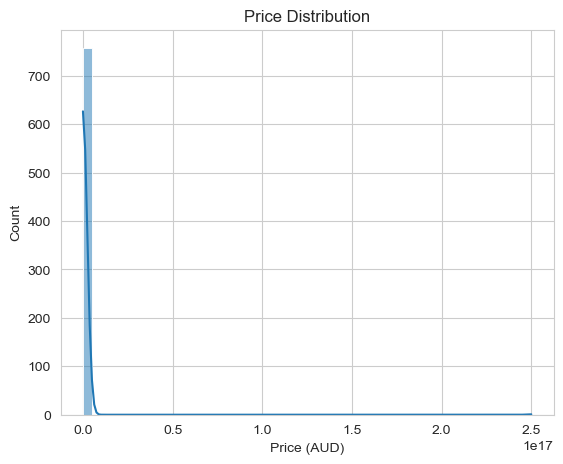

In [21]:
# price distribution
plt.figure(figsize=(14, 5))
plt.subplot(1, 2,2)
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Price Distribution')
plt.xlabel('Price (AUD)')

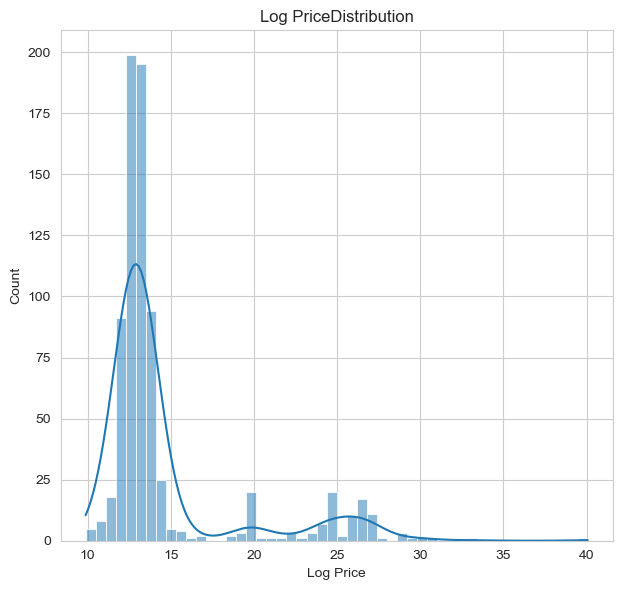

In [22]:
plt.subplot(1,2,2)
sns.histplot(df['log_price'], kde=True, bins=50)
plt.title('Log PriceDistribution')
plt.xlabel('Log Price')
plt.tight_layout()
plt.show()

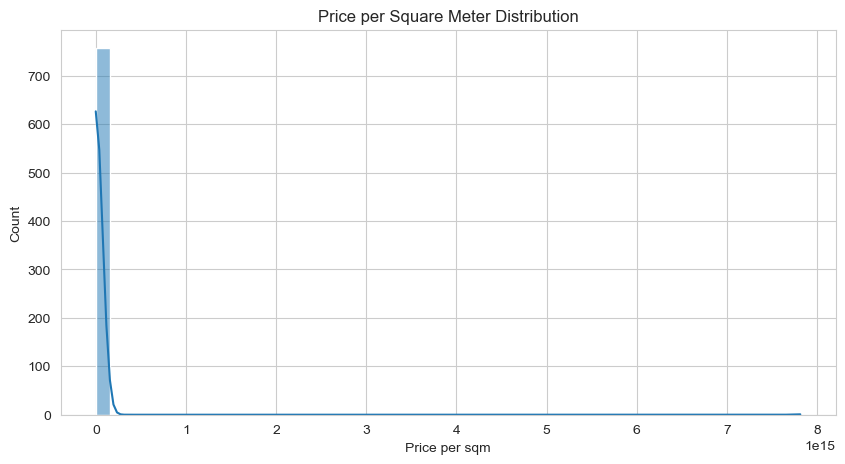

In [23]:
# price per sqm distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price_per_sqm'], kde=True, bins=50)
plt.title('Price per Square Meter Distribution')
plt.xlabel('Price per sqm')
plt.show()

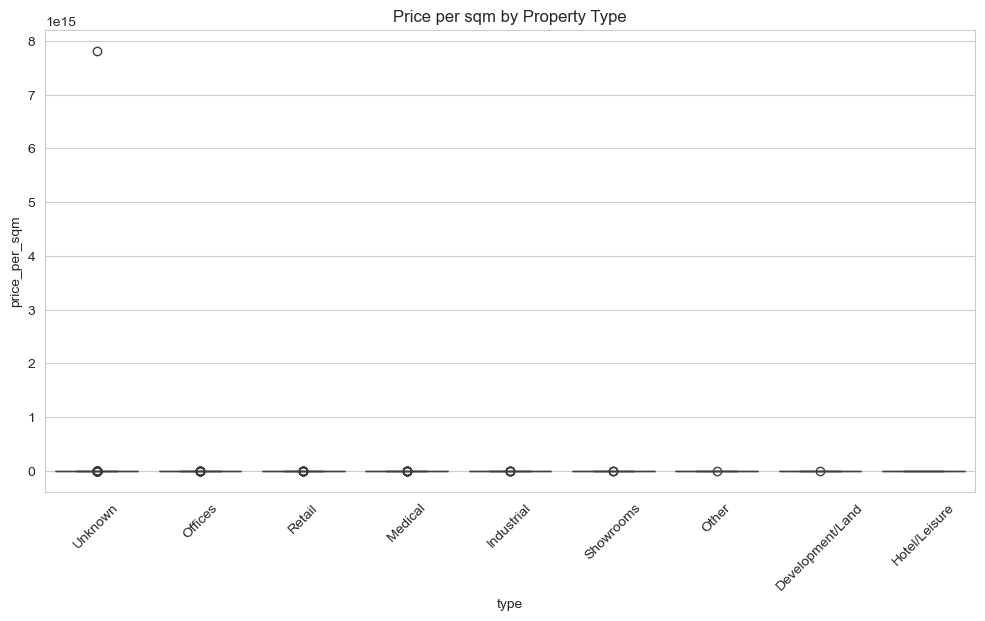

In [24]:
# by property type
plt.figure(figsize=(12, 6))
type_order = df['type'].value_counts().head(10).index
sns.boxplot(data=df, x='type', y='price_per_sqm', order=type_order)
plt.xticks(rotation=45)
plt.title('Price per sqm by Property Type')
plt.show()

In [25]:
# Basic statistics
print("Key statistics:")
print(df[['price', 'area', 'price_per_sqm']].describe().round(2))
print("\nTop 10 prperty types:")
print(df['type'].value_counts().head(10))

Key statistics:
              price    area  price_per_sqm
count  7.580000e+02  758.00   7.580000e+02
mean   3.302741e+14  107.82   1.031394e+13
std    9.080418e+15   52.31   2.837632e+14
min    1.950000e+04   12.60   1.258100e+02
25%    2.792500e+05   61.00   2.869220e+03
50%    4.720000e+05  102.00   4.950600e+03
75%    9.500000e+05  153.75   1.008103e+04
max    2.500005e+17  200.00   7.812517e+15

Top 10 prperty types:
type
Unknown             399
Offices             130
Retail               69
Medical              61
Industrial           46
Showrooms            28
Other                13
Development/Land      9
Hotel/Leisure         3
Name: count, dtype: int64


In [26]:
import plotly.express as px
plt.rcParams['figure.figsize'] = (15, 10)

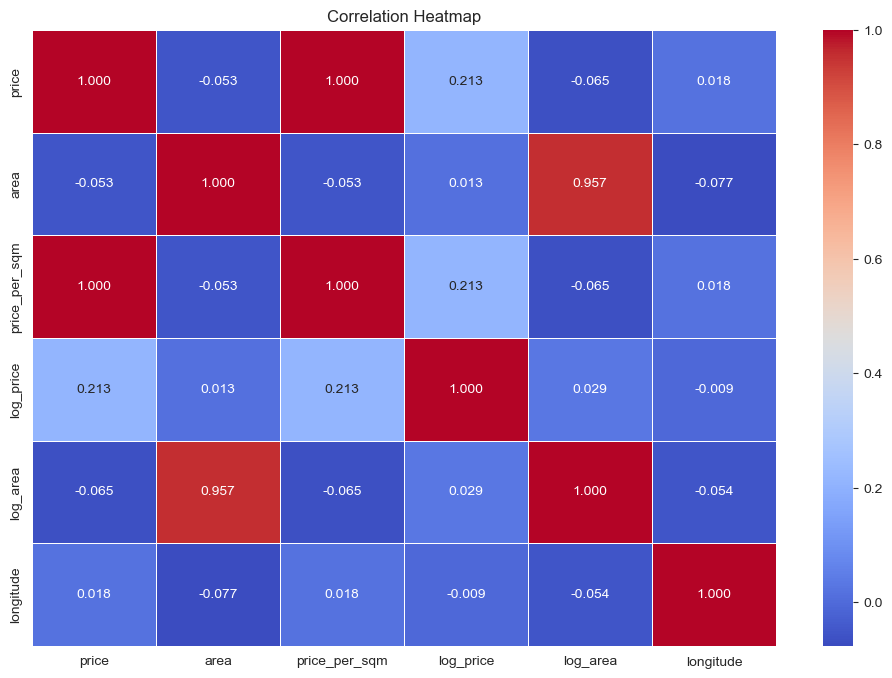

In [27]:
# correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = ['price', 'area', 'price_per_sqm', 'log_price', 'log_area', 'longitude']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

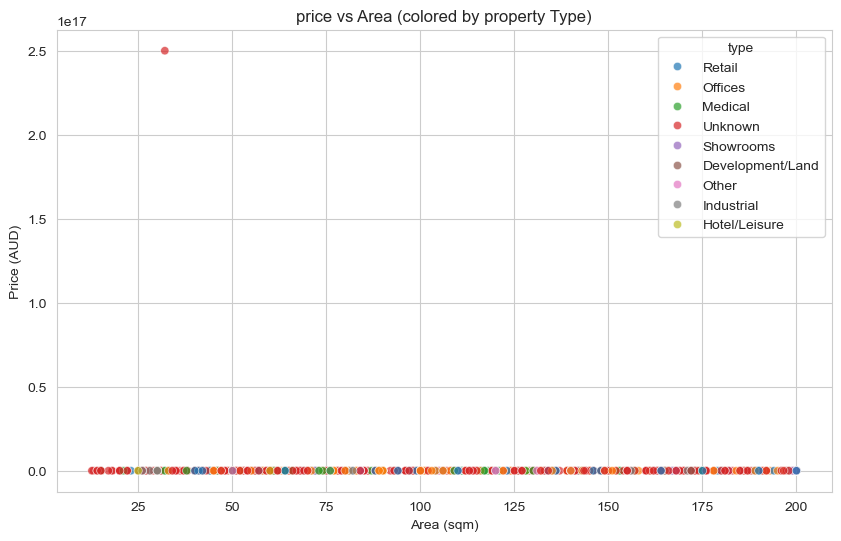

In [28]:
# price vs area scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='price', hue='type', alpha=0.7)
plt.title('price vs Area (colored by property Type)')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (AUD)')
plt.show()

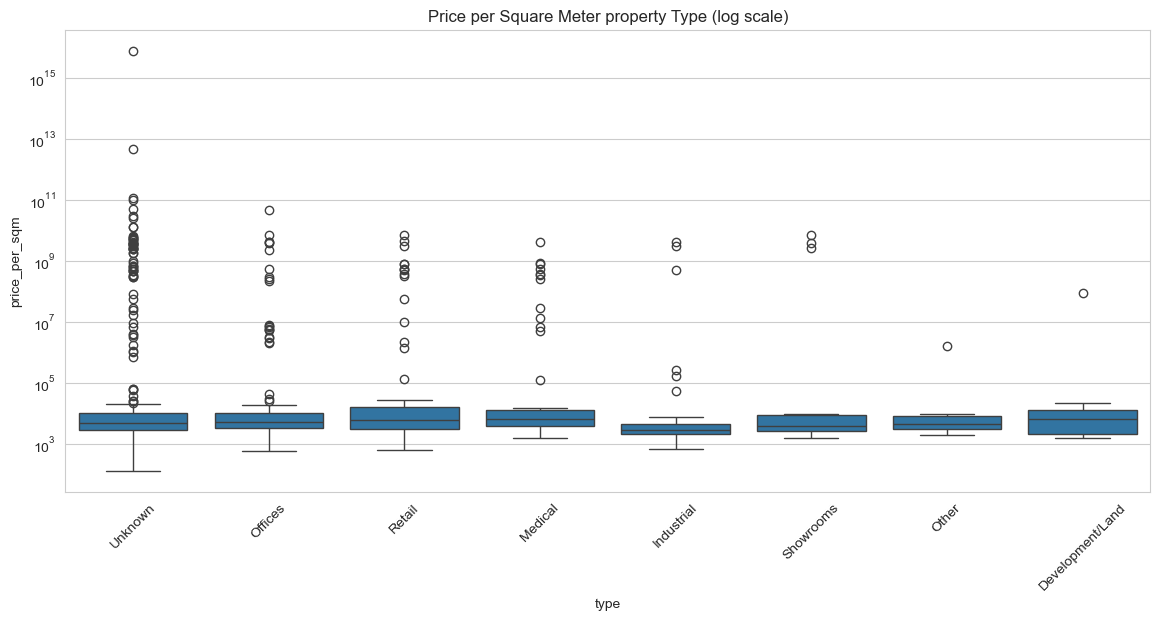

In [29]:
# price per sqm by type type(cleaned version)
plt.figure(figsize=(14, 6))
top_types = df['type'].value_counts().head(8).index
sns.boxplot(data=df[df['type'].isin(top_types)],
            x='type', y='price_per_sqm', order=top_types)
plt.yscale('log')
plt.title('Price per Square Meter property Type (log scale)')
plt.xticks(rotation=45)
plt.show()

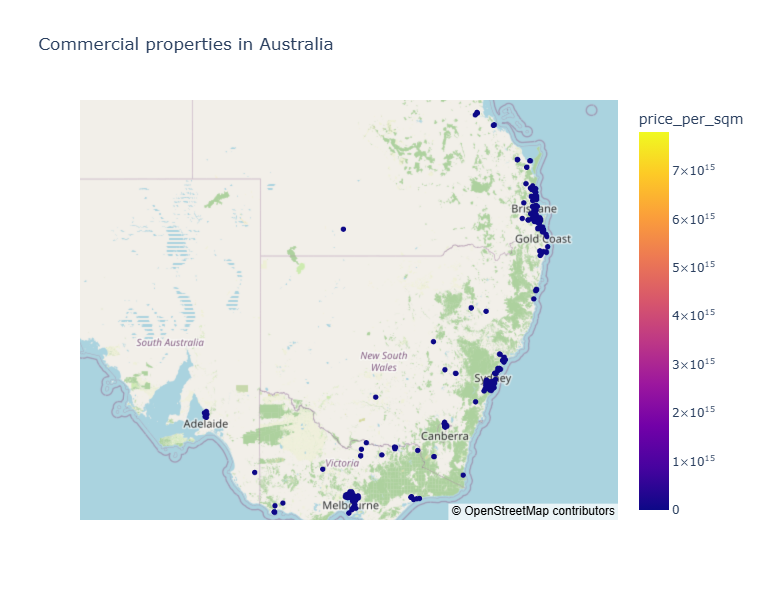

In [30]:
# Geospatial Distribution
fig = px.scatter_mapbox(df,
                        lat='lattitude',
                        lon='longitude',
                        hover_name='title',
                        hover_data=['price', 'area', 'type', 'price_per_sqm'],
                        color='price_per_sqm',
                        color_continuous_scale='plasma',
                        zoom=4,
                        height=600,
                        title="Commercial properties in Australia")
fig.update_layout(mapbox_style="open-street-map")
fig.show()
                        
                    

In [31]:
!pip install wordcloud
from wordcloud import WordCloud

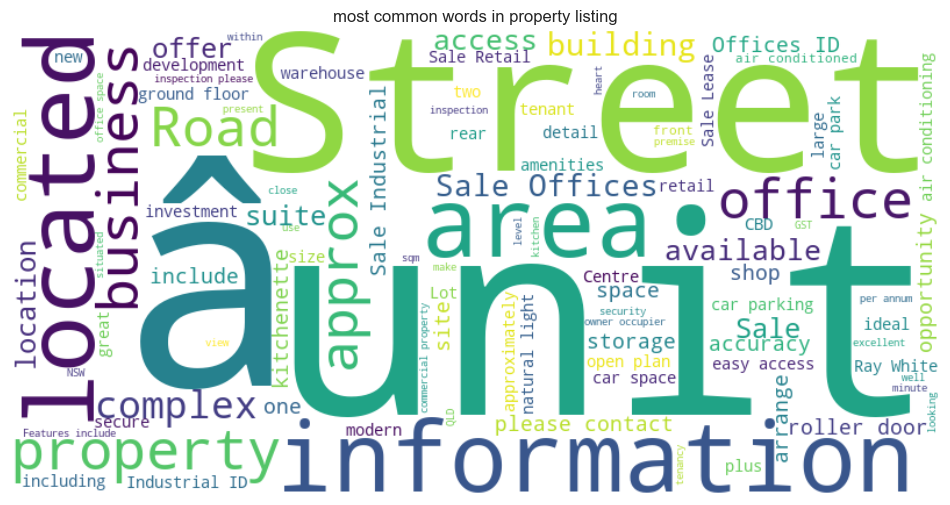

In [32]:
# text analysis
all_text = ''.join(df['title'].fillna('') + '' + df['text'].fillna(''))
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=100, colormap='viridis').generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('most common words in property listing')
plt.show()

In [33]:
 # summary
print("==Key Insights ==")
print("\nTop 10 property types:")
print(df['type'].value_counts().head(10))
print("\nMedian Price per sqm by type:")
print(df.groupby('type')['price_per_sqm'].median().sort_values(ascending=False).head(10))

      

==Key Insights ==

Top 10 property types:
type
Unknown             399
Offices             130
Retail               69
Medical              61
Industrial           46
Showrooms            28
Other                13
Development/Land      9
Hotel/Leisure         3
Name: count, dtype: int64

Median Price per sqm by type:
type
Hotel/Leisure       10000.000000
Medical              6571.428571
Development/Land     6357.575758
Retail               5750.000000
Offices              4961.538462
Unknown              4900.000000
Other                4490.000000
Showrooms            3731.482042
Industrial           2745.967742
Name: price_per_sqm, dtype: float64


In [34]:
print("\nAverage Price by state (if available):")
if 'state' in df.columns:
    print(df.groupby('state')['price'].mean().sort_values(ascending=False))
else:
    # extracting state roughly from address
    df['state'] = df['address'].str.extract(r'(NSW|VIC|QLD|WA|SA|TAS|ACT|NT)', expand=False)
    print(df.groupby('state')['price'].mean().sort_values(ascending=False))
print(f"\nTotal Properties Analyzed:{len(df)}")


Average Price by state (if available):
state
QLD    5.580003e+13
NT     2.128385e+11
WA     1.644509e+10
SA     5.983097e+09
NSW    4.167124e+09
ACT    6.837500e+05
Name: price, dtype: float64

Total Properties Analyzed:758


# Feature Engineering

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
# Location Features
df['state'] = df['address'].str.extract(r'(NSW|VIC|QLD|WA|SA|TAS|ACT|NT)', expand=False)
# Rough distance to major cities (simplified)
def get_state_group(state):
    if state == 'NSW': return 'Syydney'
    elif state == 'VIC': return 'Melbourne'
    elif state == 'qld': return 'Brisbane'
    else: return 'other'
df['major_city'] = df['state'].apply(get_state_group)

In [37]:
# size categories
df['size_category'] = pd.cut(df['area'],
                             bins=[0, 50, 100, 200, 500, np.inf],
                             labels=['small', 'Medium', 'Large', 'Very Large', 'Huge'])

In [38]:
# price efficiency
df['price_per_sqm'] = df['price'] / df['area']
df['log_price_per_sqm'] = np.log1p(df['price_per_sqm'])

In [39]:
# text features
df['full_text'] = (df['title'].fillna('') + " " + df['text'].fillna('')).str.lower()
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1,2))
text_features = tfidf.fit_transform(df['full_text'])

In [40]:
# convert to dataframe and join
text_df = pd.DataFrame(text_features.toarray(),
                       columns=[f'tidf_{word}' for word in tfidf.get_feature_names_out()],
                       index=df.index)
df = pd.concat([df, text_df], axis=1)
print("Text features added:", text_df.shape[1])

Text features added: 50


In [41]:
#Pseudo ROI/Investment attractiveness score
# Higher score = potentially better investment (lower price_per_sqm +good text +good type)
df['price_per_sqm_rank'] = df['price_per_sqm'].rank(pct=True)
df['text_length'] = df['full_text'].str.len()
# Investment score (higher = better)
df['investment_score'] = (
    (1-df['price_per_sqm_rank']) * 0.5 +
    (df['text_length'] / df['text_length'].max()) * 0.2 +
    (df['nbn'].str.contains('Service Available|Yes', case=False, na=False).astype(int)) * 0.15 +
    (df['type'].isin(['Retail', 'Industrial', 'Offices']).astype(int)) * 0.15
)

In [42]:
print("New shape:", df.shape)
print("\nInvestment score summary:")
print(df['investment_score'].describe().round(3))
#Top 10 best investment 
print("\nTop 10 potential Investments:")
print(df.nlargest(10, 'investment_score')[['title', 'type', 'price', 'area', 'price_per_sqm', 'investment_score']])

New shape: (758, 71)

Investment score summary:
count    758.000
mean       0.449
std        0.177
min        0.038
25%        0.320
50%        0.442
75%        0.588
max        0.870
Name: investment_score, dtype: float64

Top 10 potential Investments:
                                                  title        type     price  \
165   49 Fitzgerald Esplanade, Innisfail, QLD 4860 -...      Retail  240000.0   
997   59 Hanson St, Corryong, VIC 3707 - For Sale - ...      Retail   90000.0   
447   69 Presto Avenue, Mackay Harbour, QLD 4740 - F...  Industrial  130000.0   
388   7/17 Liuzzi Street, Pialba, QLD 4655 - For Sal...      Retail  210000.0   
559   12/172 North Road, Woodridge, QLD 4114 - For S...  Industrial  228000.0   
1422  5/24 Hammond Road, Cockburn Central, WA 6164 -...     Offices  339000.0   
1411  1/4 Chisholm Court, Wodonga, VIC 3690 - Sold -...  Industrial  150000.0   
465   18/9 Murrena Street, Wedgefield, WA 6721 - For...      Retail   99000.0   
1407  2/4 Chishol

In [43]:
!pip install xgboost

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import  xgboost as xgb
import numpy as np


In [105]:
X = df_cleaner.drop(columns=['price', 'log_price', 'price_per_sqm', 'full_text', 
                            'title', 'address', 'text', 'investment_score', 
                            'price_per_sqm_rank', 'state', 'Unnamed: 0'], 
                   errors='ignore')

y = np.log1p(df_cleaner['price_per_sqm'])
print("Number of features used:", X.shape[1])

Number of features used: 60


In [106]:
# identifying categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numerical columns:", len(numerical_cols))

Categorical columns: ['nbn', 'type', 'major_city', 'size_category']
Numerical columns: 56


In [107]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

In [108]:
#splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
# full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=400,
        learning_rates=0.08,
        max_depth=5,
        subsamples=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

                    
        

In [111]:
#Train
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
# predict
y_pred = model_pipeline.predict(X_test)

In [113]:
print("\n=== MODEL PERFORMANCE AFTER PREPROCESSING ===")
print("MAE: ", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE: ", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("R²: ",round(r2_score(y_test, y_pred), 4))



=== MODEL PERFORMANCE AFTER PREPROCESSING ===
MAE:  0.13
RMSE:  0.24
R²:  0.9956


# SHAP Analysis

In [67]:
!pip install shap
import shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 411.9 kB/s  0:00:01

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- --------

In [69]:
# using the tarined pipeline
preprocessor = model_pipeline.named_steps['preprocessor']
xgb_model = model_pipeline.named_steps['regressor']
# Transforming test data
X_test_transformed = preprocessor.transform(X_test)
# creating SHAP explainer
explainer = shap.TreeExplainer(xgb_model, feature_perturbation='interventional')
#calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

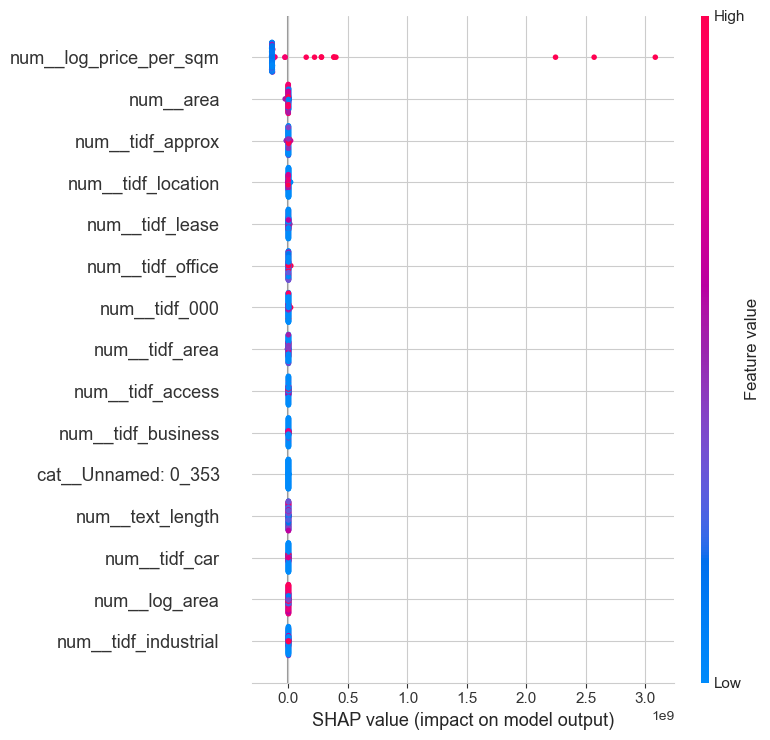

<function matplotlib.pyplot.show(close=None, block=None)>

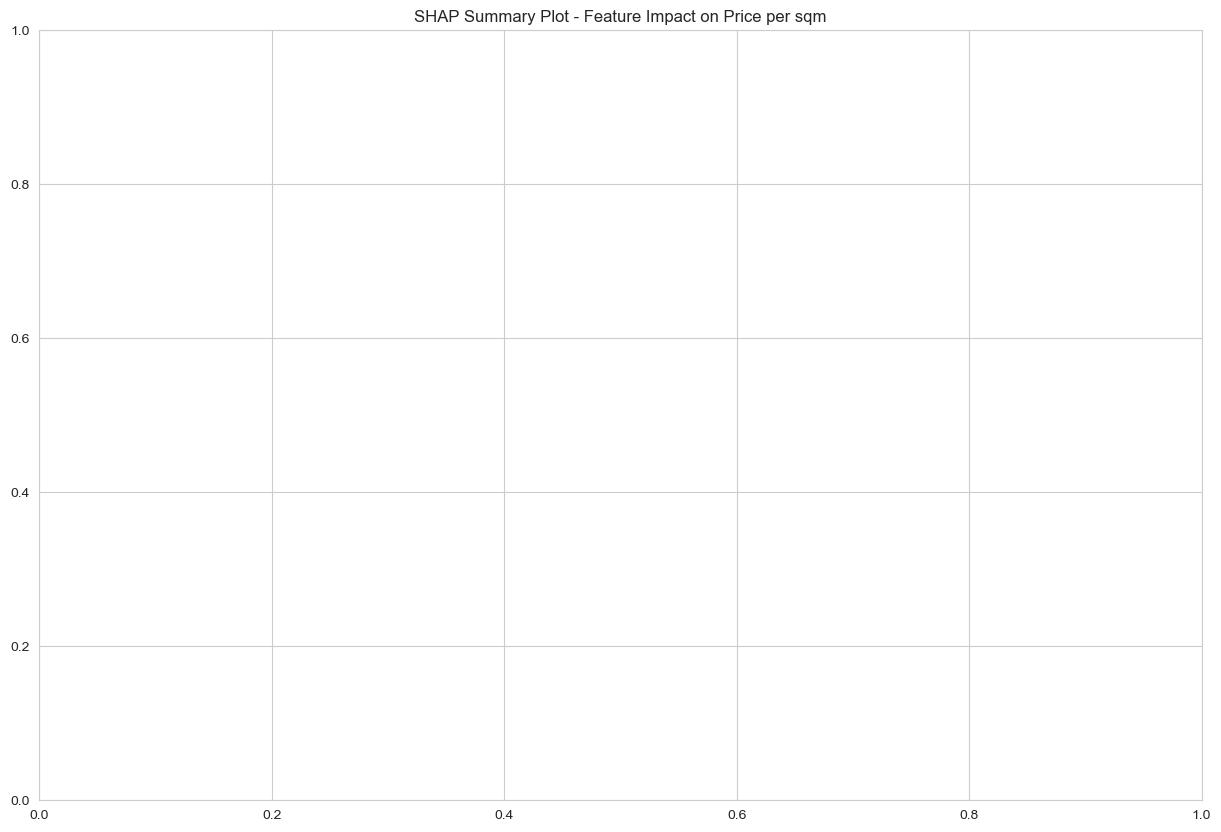

In [72]:
# summary plot (Global importance)
plt.figure(figsize= (12,8))
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=preprocessor.get_feature_names_out(),
                  max_display=15)
plt.title('SHAP Summary Plot - Feature Impact on Price per sqm')
plt.show
                  

In [74]:
# Top 10 most 10 features
shap_importances = np.abs(shap_values).mean(0)
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': shap_importances
}).sort_values('importance', ascending=False)
print("===Top 10 Most important feature (SHAP) ===")
print(importance_df.head(10))

===Top 10 Most important feature (SHAP) ===
                   feature    importance
4   num__log_price_per_sqm  1.944241e+08
0                num__area  1.478320e+06
9         num__tidf_approx  1.034627e+06
33      num__tidf_location  1.029230e+06
31         num__tidf_lease  3.546850e+05
36        num__tidf_office  2.685904e+05
5            num__tidf_000  2.342912e+05
10          num__tidf_area  2.029984e+05
6         num__tidf_access  1.914325e+05
13      num__tidf_business  1.910285e+05


In [81]:
# Single Prediction Explanation
idx = 0 #changing this to see different test samples
print(f"\nExplanation for Test Sample")
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_transformed[idx],
    feature_names=preprocessor.get_feature_names_out()
)
shap.plots.force(explainer.expected_value, shap_values[idx],
                 X_test_transformed[idx],
                 feature_names=preprocessor.get_feature_names_out())
      
      


Explanation for Test Sample


# ROI Calculator Function

In [120]:
import joblib
# saving the model
joblib.dump(model_pipeline, 'cre_roi_model.pkl')

['cre_roi_model.pkl']

In [121]:
# loading the model
model_pipeline = joblib.load('cre_roi_model.pkl')

In [124]:
def predict_commercial_roi(area, property_type, nbn_status, description="", latitude=None, longitude=None):
    """
    Simple ROI Predictor for new commercial properties
    """
    input_data ={
       'area': [area],
       'type': [property_type],
       'full_text': [description.lower()],
       'latitude': [latitude if latitude else -33.8688],
       'longitude': [longitude if longitude else 151.2093]
    }
    input_df = pd.DataFrame(input_data)
    # Add basic derived features (to avoid errors)
    input_df['price_per_sqm'] = 0
    input_df['log_price_per_sqm'] = 0
    try:
        pred_per_price_sqm = model_pipeline.predict(input_df)[0]
        estimated_price = pred_price_per_sqm * area
        # Simple ROI proxy (assuming 6-8% annual yield)
        est_annual_yield = estimated_price *0.07
        roi_score = 0.65
        return {
            "estimated_price": round(estimated_price, 2),
            "price_per_sqm": round(pre_per_per_sqm, 2),
            "etimated_annual_income": round(est_annual_yield, 2),
            "investment_score": round(roi_score, 3),
            "recommendation": "Strong Buy" if roi_score > 0.6 else "Good Opportunity" if roi_score > 0.45 else "Average"
        }
    except Exception as e:
        return {"error": str(e)}
        

In [125]:
# Testing
test_result = predict_commercial_roi(
    area=120,
    property_type="Retail",
    nbn_status="Service Available",
    description="Mordern shop with high foot traffic in busy area"
)
print(test_result)


{'error': "columns are missing: {'tidf_cbd', 'tidf_000', 'tidf_property', 'tidf_great', 'tidf_opportunity', 'major_city', 'tidf_area', 'tidf_parking', 'tidf_information', 'tidf_office', 'tidf_retail', 'tidf_road', 'tidf_street', 'tidf_offices', 'tidf_contact', 'tidf_park', 'tidf_sale', 'tidf_inspection', 'tidf_industrial', 'tidf_gst', 'tidf_features', 'log_area', 'tidf_air', 'tidf_nsw', 'tidf_units', 'tidf_new', 'tidf_door', 'tidf_space', 'tidf_building', 'tidf_complex', 'lattitude', 'tidf_commercial', 'tidf_unit', 'tidf_secure', 'text_length', 'tidf_approx', 'tidf_high', 'tidf_centre', 'tidf_investment', 'size_category', 'tidf_car', 'tidf_amenities', 'tidf_located', 'tidf_qld', 'tidf_suite', 'tidf_available', 'tidf_site', 'tidf_lease', 'tidf_id', 'tidf_access', 'tidf_business', 'nbn', 'tidf_storage', 'tidf_sale offices', 'tidf_location', 'tidf_floor'}"}


In [136]:
def predict_commercial_roi(area, property_type, nbn_status, description="", latitude=None, longitude=None):
    """
    Simple ROI Predictor for new commercial properties
    """
    # creating a basic input
    input_dict = {
       'area': [float(area)],
       'type': [str(property_type)],
       'nbn': [str(nbn_status)],
       'full_text': [str(description).lower()],
       'latitude': [float(latitude) if latitude else -33.8688],
       'longitude': [float(longitude) if longitude else 151.2093],
       'text_length': [len(str(description))],
        
        
    }
    input_df = pd.DataFrame(input_dict)

    # adding the most important basic features the model expects
    input_df['log_area'] = np.log1p(input_df['area'])
    input_df['major_city'] = 'other'
    input_df['size_category'] = pd.cut([area], bins=[0, 50, 100, 200, 500, np.inf],
                                     labels=['Small', 'Medium', 'Large', 'Very Large', 'Huge'])[0]
    # Filling missing columns with zeros
    for col in model_pipeline.feature_names_in_:
        if col not in input_df.columns:
            input_df[col] = 0
    # making predictions
    try:
        pred_per_price_sqm = model_pipeline.predict(input_df)[0]
        estimated_price = pred_per_price_sqm * area
        # simple investment score
        investment_score = 0.55
        return {
            "estimated_price": round(float(estimated_price), 2),
            "price_per_sqm": round(float(pred_per_price_sqm), 2),
            "investment_score": round(float(investment_score), 3),
            "recommendation": "Good Opportunity"
        }
    except Exception as e:
        return {"error": str(e)}
        

In [137]:
# Testing
test_result = predict_commercial_roi(
    area=120,
    property_type="Retail",
    nbn_status="Service Available",
    description="Mordern shop with high foot traffic in busy area"
)
print(test_result)

{'estimated_price': 615.33, 'price_per_sqm': 5.13, 'investment_score': 0.55, 'recommendation': 'Good Opportunity'}
